# Part 3 · Semantic search over 300 reviews

**Building Agentic AI — Day 1, 11:30–12:15**

Welcome back. We previously computed cosine similarity between 8 sentences.
Now we do it *for real*: you've just joined **Playfield**, a small indie game
storefront, as its first data person. You have 20 games, 300 player reviews,
and one recurring request from the studios: *"what are players actually saying?"*

In this notebook you build the answer machine: **semantic search** — find reviews
by *meaning*, not keywords. It's the "R" in RAG, and on Day 3 your agent will
call the function you write today.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv("../.env", override=True)  # .env wins over stale keys inherited from the kernel's environment
client = genai.Client()

EMBED_MODEL = "gemini-embedding-001"

pd.set_option("display.max_colwidth", 100)

## 1. Meet the dataset

Two CSVs — the game catalog and the player reviews. (A crash course in `pandas`
happens naturally in the next ten cells; watch what each line does to the table.)

In [2]:
games = pd.read_csv("../data/games.csv")
games

,game_id,title,genre,price_eur,release_year,developer
0,g01,Neon Drift Racers,Arcade racing,19.99,2024,Velocity Forge
1,g02,Dungeon Sprouts,Cozy roguelite,14.99,2023,Tiny Cauldron
2,g03,Star Salvage Crew,Co-op space sim,24.99,2025,Orbital Labs
3,g04,Castle Contractors,Building sim,29.99,2024,Drawbridge Digital
4,g05,Pixel Pirates Online,Free-to-play MMO,0.00,2022,Kraken Interactive
5,g06,Kernel Panic,Hacking roguelike,12.99,2025,Null Pointer Games
6,g07,Haunted Spreadsheet,Horror comedy sim,9.99,2024,Cursed Cell Studio
7,g08,Orbit Fall,Physics platformer,7.99,2023,Weightless Whale
8,g09,Moth Light,Metroidvania,17.99,2025,Lantern Collective
9,g10,Turbo Goat Simulator 9,Meme sandbox,6.99,2024,Chaos Pasture


In [3]:
reviews = pd.read_csv("../data/reviews.csv")
print(f"{len(reviews)} reviews")
reviews.head(3)

300 reviews


,review_id,game_id,author,hours_played,recommended,helpful_votes,date,review_text
0,r001,g14,irrigation_nation,36.0,True,9,2025-11-22,The customization depth surprised me: swapped my Trowel-9's shoulder cannon for an irrigation dr...
1,r002,g18,prodigal_planter,344.7,True,48,2026-05-22,Came back after a year away for the 2.0 Reforged update and it is everything the old roadmap pro...
2,r003,g11,pawn_fodder,6.3,False,19,2023-08-30,Rank 2 and I keep getting paired against actual grandmasters. Why.


`pandas` one-liners answer the easy questions instantly:

In [4]:
reviews["recommended"].mean()          # fraction of thumbs-up overall

np.float64(0.7033333333333334)

In [5]:
reviews["hours_played"].describe().round(1)

count     300.0
mean       55.0
std       104.8
min         0.8
25%        12.0
50%        28.6
75%        58.1
max      1150.0
Name: hours_played, dtype: float64

`merge` joins the two tables on `game_id`, so every review knows its game's
title, genre and price — we'll work with this combined table from now on:

In [6]:
df = reviews.merge(games, on="game_id")
df[["review_id", "title", "recommended", "hours_played", "review_text"]].head(3)

,review_id,title,recommended,hours_played,review_text
0,r001,Mecha Garden,True,36.0,The customization depth surprised me: swapped my Trowel-9's shoulder cannon for an irrigation dr...
1,r002,Farm & Forge,True,344.7,Came back after a year away for the 2.0 Reforged update and it is everything the old roadmap pro...
2,r003,Chess Royale 100,False,6.3,Rank 2 and I keep getting paired against actual grandmasters. Why.


Which games do players love — and which are in trouble?

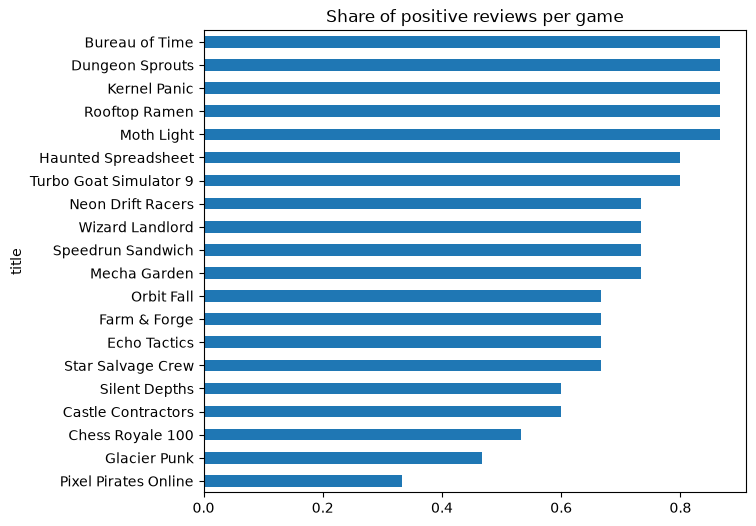

In [7]:
rating = df.groupby("title")["recommended"].mean().sort_values()
rating.plot(kind="barh", figsize=(7, 6), title="Share of positive reviews per game");

Read a few raw reviews to get a feel for the *texture* of this data — typos,
sarcasm, ALL CAPS, the occasional Romanian:

In [8]:
for text in df.sample(3, random_state=7)["review_text"]:
    print("—" * 70)
    print(text)

——————————————————————————————————————————————————————————————————————
As someone who has finished basically every metroidvania worth playing: the movement kit here is top three ever. The Chandler fight forces you to use every tool you've unlocked and it's glorious. Ability gating is smart, secrets reward genuine curiosity, and yes, you can break the intended route in at least four places. The map deserved another design pass, but the world underneath it is exceptional.
——————————————————————————————————————————————————————————————————————
Finished in one hour fifty-four. Even at ten euro that stings when the store page says nothing about length. Brilliant concept, criminally brief. Wait for a sale or a content update.
——————————————————————————————————————————————————————————————————————
Bought it right after the big 2.0 update. Zero regrets.


## 2. Keyword search — and where it breaks

The obvious approach: `str.contains`.

In [9]:
def keyword_search(query):
    hits = df[df["review_text"].str.contains(query, case=False, regex=False)]
    return hits[["title", "review_text"]]


keyword_search("crash").head()

,title,review_text
3,Neon Drift Racers,"Came back after patch 1.4 and the crashing is completely gone. Three-hour session last night, ze..."
124,Turbo Goat Simulator 9,"Strapped a jetpack to my goat, crashed a wedding, got the bride's bouquet stuck to my tongue, dr..."
187,Silent Depths,Save file vanished after a crash on Deck C. My support ticket has been open for three weeks with...
219,Star Salvage Crew,"The January netcode overhaul actually delivered. Movement is server-side now, rubber-banding is ..."
249,Neon Drift Racers,"Loved this game until patch 1.3. Now it crashes to desktop every second or third race, usually r..."


Works! Until the player types something the reviewer didn't:

In [10]:
print(len(keyword_search("crash")), "hits for 'crash'")
print(len(keyword_search("game keeps freezing")), "hits for 'game keeps freezing'")
print(len(keyword_search("predatory monetization")), "hits for 'predatory monetization'")

5 hits for 'crash'
0 hits for 'game keeps freezing'
0 hits for 'predatory monetization'


Zero hits — yet you *know* reviews complain about freezes and cash grabs; they just
use different words ("CTD", "hangs", "wallet warriors", "pay-to-win"...).
Keyword search matches **spelling**. We need to match **meaning**.

## 3. Embed the whole corpus (batched, cached, retry-safe)

Same as this morning, at scale: one 768-dim vector per review. Three bits of
engineering that mark the difference between a demo and something that survives
contact with reality:

- **batching** — the API takes up to ~100 texts per call, so we send chunks,
- **retries with backoff** — free-tier rate limits (HTTP 429) are a *when*, not an *if*,
- **caching** — embeddings don't change; compute once, save to disk, reload forever.

In [13]:
CACHE = Path("cache")
CACHE.mkdir(exist_ok=True)
EMB_FILE = CACHE / "review_embeddings.npy"


def embed_texts(texts, task_type, batch_size=64):
    """Embed a list of texts → normalized (len(texts), 768) matrix."""
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]
        for attempt in range(7):
            try:
                result = client.models.embed_content(
                    model=EMBED_MODEL,
                    contents=batch,
                    config=types.EmbedContentConfig(
                        task_type=task_type,
                        output_dimensionality=768,
                    ),
                )
                vectors.extend(e.values for e in result.embeddings)
                break
            except genai.errors.APIError as err:
                wait = 2**attempt
                print(f"  API error {err.code}: {err.message}")
                print(f"  retrying in {wait}s…")
                time.sleep(wait)
        else:
            raise RuntimeError("embedding failed after 7 attempts")
        print(f"  embedded {min(start + batch_size, len(texts))}/{len(texts)}")
    E = np.array(vectors)
    return E / np.linalg.norm(E, axis=1, keepdims=True)


if EMB_FILE.exists():
    doc_vecs = np.load(EMB_FILE)
    print("loaded from cache ✅")
else:
    doc_vecs = embed_texts(df["review_text"].tolist(), task_type="RETRIEVAL_DOCUMENT")
    np.save(EMB_FILE, doc_vecs)

doc_vecs.shape

  embedded 64/300
  API error 429: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 100, model: gemini-embedding-1.0
Please retry in 8.637527922s.
  retrying in 1s…
  API error 429: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 100, model: gemini-embedding-1.0
Please retry in 7.42399077s.
  retrying in 2s…
  API error 429: You exceeded your current quota, please check your plan and billing details. For

(300, 768)

One subtlety: `task_type="RETRIEVAL_DOCUMENT"` for the corpus, but
`RETRIEVAL_QUERY` for searches. Queries and documents are phrased differently
("crashes on startup?" vs "the game died again, third time today") — Gemini
embeddings are trained to map the *question* and the *answer* close together
when you label which is which.

## 4. The search function — 15 lines, as promised

In [14]:
def search(query, top_k=5):
    result = client.models.embed_content(
        model=EMBED_MODEL,
        contents=query,
        config=types.EmbedContentConfig(
            task_type="RETRIEVAL_QUERY",
            output_dimensionality=768,
        ),
    )
    q = np.array(result.embeddings[0].values)
    q = q / np.linalg.norm(q)

    scores = doc_vecs @ q                      # cosine similarity vs every review at once
    top = np.argsort(scores)[::-1][:top_k]     # best k indices

    hits = df.iloc[top][["review_id", "title", "recommended", "review_text"]].copy()
    hits.insert(0, "score", scores[top].round(3))
    return hits

That's the whole engine. Let's interrogate it — starting with the query that
keyword search fumbled:

In [14]:
search("game keeps freezing")

,score,review_id,title,recommended,review_text
200,0.670,r201,Neon Drift Racers,False,I was 40 hours in and hosting weekly time-trial nights with my club. Since the update the game f...
36,0.660,r037,Neon Drift Racers,True,"game dies after the update at least once a night, usualy mid drift. still cant quit it tho. the ..."
120,0.653,r121,Castle Contractors,False,my laptop sounds like a trebuchet winding up whenever i load my big castle. 12 fps in the courty...
52,0.649,r053,Glacier Punk,True,"Built my base into the side of a crevasse and rigged geothermal heating, then a patch moved the ..."
62,0.648,r063,Neon Drift Racers,False,hangs on the loading screen since the update. stared at neon for ten minutes.


In [15]:
search("predatory monetization")

,score,review_id,title,recommended,review_text
42,0.682,r043,Echo Tactics,False,"Half the units are paywalled. The Iron Choir pack alone costs 15 euro on top of a 25 euro game, ..."
208,0.678,r209,Pixel Pirates Online,False,"free to play, pay to win, hard to quit, uninstalled anyway."
39,0.661,r040,Pixel Pirates Online,False,"fomo pass, login queue, whale food. im out."
213,0.645,r214,Pixel Pirates Online,False,As a free player I grinded three weeks for the storm sails. A whale buys them in three seconds w...
266,0.645,r267,Echo Tactics,False,Base game ships with twelve units and the balance patch notes casually discuss units I do not ev...


In [16]:
search("this game made me cry")

,score,review_id,title,recommended,review_text
143,0.738,r144,Moth Light,True,I don't cry at games. I cried at this one. Every frame of the hand-drawn art looks like it took ...
275,0.720,r276,Bureau of Time,True,Solved the case at 2am and just sat there in the dark afterwards. No game has ever done that to ...
33,0.713,r034,Dungeon Sprouts,True,the little guys. the LITTLE GUYS. i grew a radish paladin and cired when he sacrificed himself f...
148,0.709,r149,Dungeon Sprouts,True,I picked this up during a rough patch of my life and it was exactly what I needed. Nothing in it...
197,0.704,r198,Farm & Forge,True,The autumn festival made me tear up a little. Farm and Forge understands coziness on a level mos...


In [17]:
search("great to play with friends")

,score,review_id,title,recommended,review_text
26,0.712,r027,Speedrun Sandwich,True,Every session generates a story. Last night someone launched the Tower of Bologna across the kit...
202,0.708,r203,Star Salvage Crew,True,friend pass means my whole squad plays on one copy. based devs.
166,0.704,r167,Speedrun Sandwich,True,"Bought four copies for game night and it paid for itself in one evening. Simple to learn, imposs..."
298,0.698,r299,Speedrun Sandwich,True,"Four players, one kitchen, ninety seconds, a bread catapult. We screamed so much the neighbors c..."
167,0.698,r168,Wizard Landlord,True,"Perfect evening game. Collect rent, read letters, laugh out loud, renovate a haunted attic, repe..."


And because embeddings are multilingual — **search in Romanian, find English reviews**:

In [18]:
search("jocul se blochează la încărcare")

,score,review_id,title,recommended,review_text
62,0.717,r063,Neon Drift Racers,False,hangs on the loading screen since the update. stared at neon for ten minutes.
211,0.673,r212,Echo Tactics,True,"Cel mai bun joc de tactica pe ture din ultimii ani, pe bune, fiecare tura e un puzzle. Singura p..."
281,0.657,r282,Dungeon Sprouts,True,l-am luat pentru nepotu-miu si acum ne certam pe rand la PC. e genul de joc care te face sa zici...
268,0.653,r269,Echo Tactics,True,45 second loads into every skirmish on a Samsung 980 Pro. An NVMe drive should not feel like a c...
153,0.651,r154,Chess Royale 100,False,"Ideea e geniala, sah cu 100 de oameni pe aceeasi tabla uriasa, ce sa zic. Dar la fiecare doua me..."


Side-by-side, the difference in one picture:

In [20]:
q = "game keeps freezing"
print(f"KEYWORD  '{q}' → {len(keyword_search(q))} hits")
print(f"SEMANTIC '{q}' → top hit: {search(q, top_k=1)['review_text'].iloc[0][:100]}…")
print(f"SEMANTIC hits  '{q}' → {len(search(q))} hits")

KEYWORD  'game keeps freezing' → 0 hits
SEMANTIC 'game keeps freezing' → top hit: I was 40 hours in and hosting weekly time-trial nights with my club. Since the update the game freez…
SEMANTIC hits  'game keeps freezing' → 5 hits


## 5. Exercises

**5.1 — Scoped search (⭐)** Write `search_game(query, title, top_k=5)` that only
searches within one game's reviews. Hint: build a boolean mask from `df["title"]`,
apply it to *both* `df` and `doc_vecs` (numpy accepts boolean masks too).

**5.2 — Most similar pair (⭐⭐)** Find the two *most similar reviews* in the whole
corpus. Hints: `S = doc_vecs @ doc_vecs.T`, kill the diagonal with
`np.fill_diagonal(S, -1)`, then `np.unravel_index(S.argmax(), S.shape)`.
Are they for the same game? Same complaint in different words?

**5.3 — More like this (⭐)** Write `more_like_this(review_id, top_k=5)`.
No new embedding needed — the review's vector is already a row of `doc_vecs`.

**5.4 — Honest search (⭐⭐)** Modify `search` to drop results scoring below a
threshold (try `0.5`). Then search for `"quantum physics homework"`.
Returning *nothing* is the correct answer — remember this on Day 3, when an
agent must decide whether its retrieval tool actually found anything.

In [25]:
# 5.1 — your code here
import os
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv("../.env", override=True)
client = genai.Client()
EMBED_MODEL = "gemini-embedding-001"
pd.set_option("display.max_colwidth", 100)

games = pd.read_csv("../data/games.csv")
df = pd.read_csv("../data/reviews.csv").merge(games, on="game_id")
doc_vecs = np.load("./cache/review_embeddings.npy")


def embed_query(query):
    result = client.models.embed_content(
        model=EMBED_MODEL,
        contents=query,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY", output_dimensionality=768),
    )
    q = np.array(result.embeddings[0].values)
    return q / np.linalg.norm(q)

# .
def search_game(query, title, top_k=5):
    mask = (df["title"] == title).to_numpy()
    sub_df, sub_vecs = df[mask], doc_vecs[mask]

    scores = sub_vecs @ embed_query(query)
    top = np.argsort(scores)[::-1][:top_k]

    hits = sub_df.iloc[top][["review_id", "recommended", "review_text"]].copy()
    hits.insert(0, "score", scores[top].round(3))
    return hits


search_game("crashes and freezes", "Neon Drift Racers")

,score,review_id,recommended,review_text
200,0.672,r201,False,I was 40 hours in and hosting weekly time-trial nights with my club. Since the update the game f...
249,0.670,r250,False,"Loved this game until patch 1.3. Now it crashes to desktop every second or third race, usually r..."
36,0.663,r037,True,"game dies after the update at least once a night, usualy mid drift. still cant quit it tho. the ..."
8,0.641,r009,True,"Still my favorite arcade racer this decade, but I CTD'd twice tonight in the middle of champions..."
3,0.637,r004,True,"Came back after patch 1.4 and the crashing is completely gone. Three-hour session last night, ze..."


In [26]:
# 5.2 — your code here
# 5.1 — your code here
import os
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv("../.env", override=True)
client = genai.Client()
EMBED_MODEL = "gemini-embedding-001"
pd.set_option("display.max_colwidth", 100)

games = pd.read_csv("../data/games.csv")
df = pd.read_csv("../data/reviews.csv").merge(games, on="game_id")
doc_vecs = np.load("./cache/review_embeddings.npy")


def embed_query(query):
    result = client.models.embed_content(
        model=EMBED_MODEL,
        contents=query,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY", output_dimensionality=768),
    )
    q = np.array(result.embeddings[0].values)
    return q / np.linalg.norm(q)

# .
S = doc_vecs @ doc_vecs.T
np.fill_diagonal(S, -1)                       # a review is always most similar to itself — exclude
i, j = np.unravel_index(S.argmax(), S.shape)

print(f"similarity {S[i, j]:.3f}\n")
for idx in (i, j):
    print(f"[{df.iloc[idx]['title']}] {df.iloc[idx]['review_text']}\n")

similarity 0.929

[Echo Tactics] increadible tactics game, teh echo system is genius and evrey mission feels handcrafted. deepest stratagy ive played in years, definately recomended for patient players

[Echo Tactics] The deepest tactics system in years, full stop. Echo positioning means every unit's past turns literally haunt the battlefield, so you are playing against your own history as much as the enemy. Every turn is a puzzle with three wrong answers and one beautiful one. I have 132 hours and I am still discovering interactions. Thinky players, this is your game.



In [27]:
# 5.3 — your code here
def more_like_this(review_id, top_k=5):
    idx = df.index[df["review_id"] == review_id][0]
    scores = doc_vecs @ doc_vecs[idx]         # the review's vector is already computed
    top = [i for i in np.argsort(scores)[::-1] if i != idx][:top_k]

    hits = df.iloc[top][["review_id", "title", "review_text"]].copy()
    hits.insert(0, "score", scores[top].round(3))
    return hits


more_like_this(df["review_id"].iloc[0])

,score,review_id,title,review_text
158,0.896,r159,Mecha Garden,"My evening routine now: clock off work, boot up, stomp the Trowel-9 out to the glowberry field, ..."
128,0.871,r129,Mecha Garden,"Piloting a 40-ton mech to gently water tomato rows should not work as a concept, and yet it's th..."
119,0.850,r120,Mecha Garden,"210 hours. The endgame is thin and I've automated almost everything, but the ritual keeps pullin..."
228,0.849,r229,Mecha Garden,My mech has a flower box mounted on its shoulder cannon. GOTY.
118,0.847,r119,Mecha Garden,"Combat is mashing one button against the same three chrome aphids, over and over. The farming ha..."


In [31]:
# 5.4 — your code here
def search_honest(query, top_k=5, min_score=0.6):
    scores = doc_vecs @ embed_query(query)
    top = np.argsort(scores)[::-1][:top_k]
    top = top[scores[top] >= min_score]

    if len(top) == 0:
        print(f"No relevant reviews found for {query!r} "
              f"(best score: {scores.max():.3f})")
        return None

    hits = df.iloc[top][["review_id", "title", "review_text"]].copy()
    hits.insert(0, "score", scores[top].round(3))
    return hits


search_honest("quantum physics homework")
#search_honest("game keeps freezing")

No relevant reviews found for 'quantum physics homework' (best score: 0.588)


---
## ✅ Checkpoint

You built a semantic search engine over a real(istic) corpus: batched + cached
embeddings, cosine ranking, honest no-answer handling. **You built the "R" in RAG.**

☕ **Short break.** In Part 4 the model starts working *for* you: turning messy
review prose into clean, analyzable rows — the last skill your Friday agent needs.